# 11. Selenium

Selenium is the counter-example to arsenic, and the pair is worth teaching
together. Both are metalloids, both are toxic as oxyanions, both are
respired by anaerobes, and both have a Se(VI)/Se(IV)/Se(0) — As(V)/As(III)/
As(0) — ladder that looks the same on paper.

The difference is that **selenium's reduced element is an environmental
sink and arsenic's is not**, and that single fact is why selenium
bioremediation works and arsenic remediation is hard.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import microbial_thermo as mt
from microbial_thermo.figures import frost_diagram, latimer_diagram, plot_frost, plot_latimer, plot_pourbaix
from microbial_thermo.figures.pourbaix import pourbaix_field, water_stability

warnings.filterwarnings("ignore", category=UserWarning)

## The ladder

In [2]:
ladder = latimer_diagram("Se", pH=7.0)
ladder.to_frame()

,oxidized,reduced,n electrons,E (V),dG (kJ/mol element),half reaction
0,SeO4--,HSeO3-,2.0,0.452674,-87.352768,SeO4-- + 3 H+ + 2 e- -> HSeO3- + H2O
1,HSeO3-,Se,4.0,0.259892,-100.303162,HSeO3- + 5 H+ + 4 e- -> Se + 3 H2O


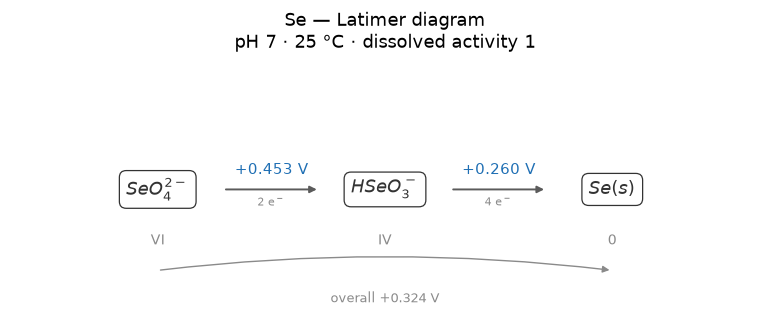

In [3]:
plot_latimer("Se", diagram=ladder)
plt.show()

Both steps are strongly favourable at pH 7 — selenate to selenite at
+0.45 V and selenite to the element at +0.26 V. Compare arsenic, where the
first step is worth +0.013 V and the second is *negative*:

In [4]:
for element in ("Se", "As"):
    steps = latimer_diagram(element, pH=7.0).steps
    chain = "   ".join(f"{s.oxidized.backend} –({s.potential:+.3f})→ {s.reduced.backend}" for s in steps)
    print(f"{element}:  {chain}")

Se:  SeO4-- –(+0.453)→ HSeO3-   HSeO3- –(+0.260)→ Se


As:  HAsO4-- –(+0.013)→ As(OH)3(aq)   As(OH)3(aq) –(-0.166)→ As


Reducing selenite all the way to elemental selenium pays. Reducing arsenite
to elemental arsenic costs. That is the whole story, and everything below is
a consequence of it.

## What is stable

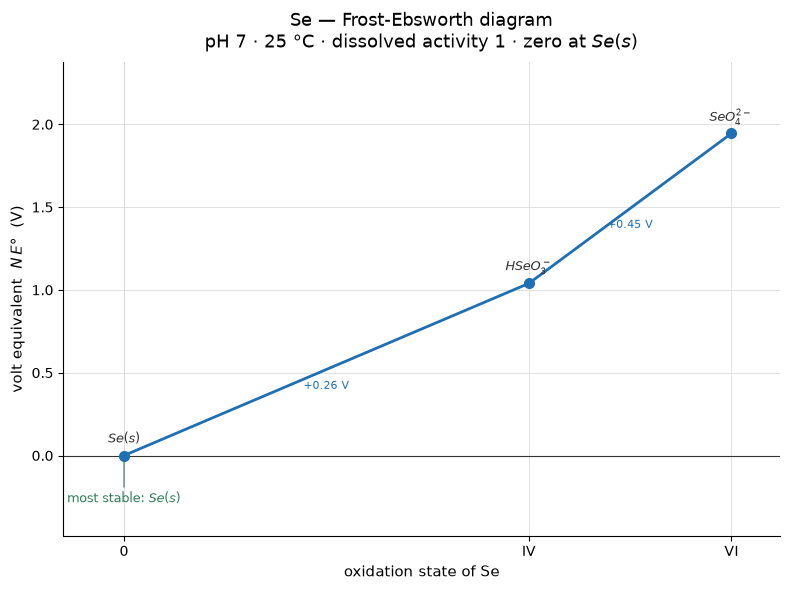

In [5]:
plot_frost("Se", pH=7.0, annotate_slopes=True)
plt.show()

In [6]:
frost = frost_diagram("Se", pH=7.0)
print("most stable at pH 7:", frost.most_stable.backend)
print("most stable at pH 0:", frost_diagram("Se", pH=0.0).most_stable.backend)

most stable at pH 7: Se
most stable at pH 0: Se


The element is the minimum at both pH values — unlike arsenic, where the
minimum moves to the dissolved arsenite by pH 7.

## Where each form lives

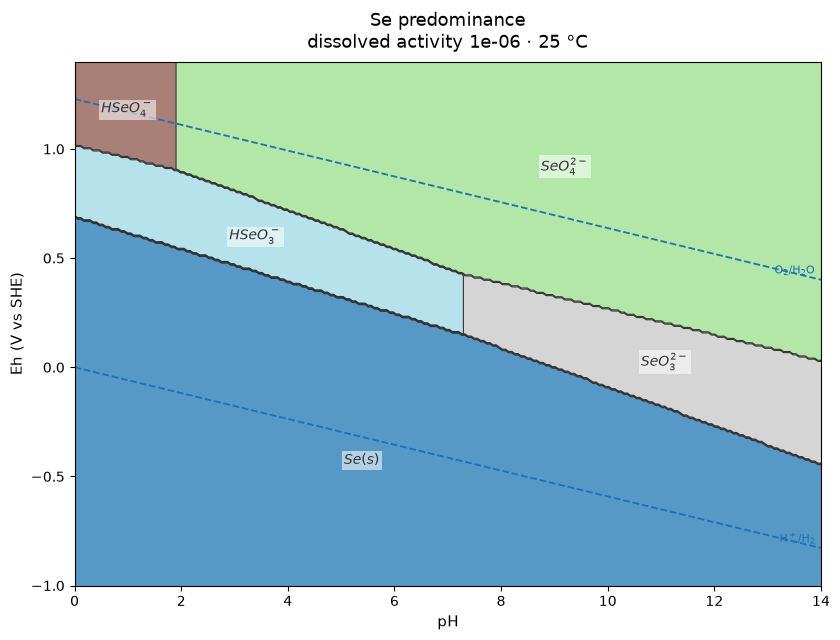

In [7]:
plot_pourbaix("Se", figsize=(8.5, 6.5))
plt.show()

## Measuring the difference

The question is how much of the *reachable* range — between the water
stability lines — each element spends as an insoluble solid.

In [8]:
ph_axis, upper, lower = water_stability(25.0)
index = int(np.argmin(abs(ph_axis - 7.0)))
window = (lower[index], upper[index])


def solid_span(element, solid, pH=7.0):
    """Volts of the water window at this pH held by the elemental solid."""
    field = pourbaix_field(element, points=241)
    column = int(np.argmin(abs(field.ph - pH)))
    wanted = field.species.index(solid)
    inside = [
        eh
        for eh, winner in zip(field.eh, field.winner[:, column])
        if window[0] <= eh <= window[1] and int(winner) == wanted
    ]
    return (max(inside) - min(inside)) if inside else 0.0


print(f"water is stable over {window[1] - window[0]:.3f} V at pH 7\n")
for element, solid in (("Se", "Se"), ("As", "As")):
    span = solid_span(element, solid)
    print(f"  elemental {element}: {span:.3f} V of that window ({span / (window[1] - window[0]):.0%})")

water is stable over 1.229 V at pH 7

  elemental Se: 0.580 V of that window (47%)
  elemental As: 0.120 V of that window (10%)


Elemental selenium holds 0.58 V — essentially the whole reducing half of
the window. Elemental arsenic holds 0.12 V, a sliver at the very bottom. An anaerobic sediment
sits comfortably inside selenium's solid field and comfortably inside
**arsenite's dissolved** field.

So the same treatment — make it anoxic, let the anaerobes respire — takes
selenium out of solution and puts arsenic into it.

## Who lives on each step

In [9]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
selenium = [
    "selenate_respiration_hydrogen",
    "selenate_respiration_acetate",
    "selenite_reduction_hydrogen",
    "selenite_reduction_acetate",
]
table = mt.energy_table(conditions).set_index("name")
table.loc[selenium][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
selenate_respiration_hydrogen,Selenate respiration with hydrogen,-82.816004,H2(g) + SeO4-- -> SeO3-- + H2O
selenate_respiration_acetate,Selenate respiration with acetate,-68.855184,1/4 Acetate + 1/4 H+ + SeO4-- -> 1/2 CO2(aq) +...
selenite_reduction_hydrogen,Selenite reduction to elemental selenium,-65.440080,H+ + H2(g) + 1/2 SeO3-- -> 1/2 Se + 3/2 H2O
selenite_reduction_acetate,Selenite reduction with acetate,-51.479260,1/4 Acetate + 5/4 H+ + 1/2 SeO3-- -> 1/2 CO2(a...


Selenate respiration on hydrogen pays about −83 kJ/mol e⁻ here: roughly
three quarters of what nitrate pays and four times what sulfate pays. That
is a comfortable living, which is why selenate-respiring bacteria are easy
to enrich and why the reaction is used industrially — feed an anaerobic
bioreactor a carbon source, and the organisms precipitate red elemental
selenium you can filter out.

There is no arsenic equivalent, because there is no arsenic solid to make.

Both steps have an entry on both donors, which is the point: **selenium
reduction is a complete two-step pathway that ends in a solid**, and either
step can be run on hydrogen or on organic carbon. That is what makes a
bioreactor design possible — feed it either, and the selenium comes out as
a filterable red precipitate.

It is worth noticing what the second step is *not* doing:

In [10]:
for name in ("selenite_reduction_acetate", "selenate_respiration_acetate"):
    print(f"{table.loc[name, 'label']:38s} {table.loc[name, 'dG per e- (kJ/mol)']:+7.1f} kJ/mol e-")

Selenite reduction with acetate          -51.5 kJ/mol e-
Selenate respiration with acetate        -68.9 kJ/mol e-


Reducing selenite to the element pays *less* per electron than reducing
selenate to selenite. An organism optimising purely for energy would stop at
selenite — and some do. The ones used industrially go the whole way, which
means the useful step for remediation is the one the organism has least
incentive to take. Enrichment conditions matter as much as thermodynamics.

### The environmental reason anyone cares

Selenium is the textbook case of a nutrient with a narrow window: essential
in selenocysteine and selenoproteins at trace level, toxic not far above it,
with the gap between the two among the smallest of any element. Irrigation
of seleniferous soils concentrates selenate in drainage water, and selenate
is the mobile, bioavailable form — the Kesterson Reservoir deformities in
the 1980s are what put selenium into environmental regulation.

The Eh–pH diagram above is the remediation strategy in one picture: get the
water into the lower half of it and the problem precipitates.

## One thing worth taking away

"Reduction immobilises metals" is one of those rules that is true often
enough to be dangerous. It is true for selenium, uranium and chromium, and
false for arsenic and iron — and which way it goes is written on the Eh–pH
diagram, in whether the reduced form has a solid field inside the water
window.

It takes about ten lines to check, as above, and it is worth checking every
time.